# Data Visualization

Visualization turns numbers into pictures that are far faster to reason about than raw tables.
Python's two core plotting libraries are **Matplotlib** (low-level, fully customizable) and
**Seaborn** (built on top of Matplotlib, higher-level, works directly with DataFrames and adds
statistical chart types).

1. Introduction to Data Visualization & Python Libraries
2. Visualization Best Practices
3. Matplotlib Line Plots
4. Axis, Labels, Legend, Alpha & Annotation
5. Multiple Plots & Subplots
6. Scatterplots
7. Pie Charts
8. Barplots
9. Seaborn Overview, Boxplots & Distribution Plots
10. Heatmaps
11. Swarmplots & Countplots
12. Pointplots

## 1. Introduction to Data Visualization & Python Libraries

`matplotlib.pyplot` is conventionally imported as `plt`, `seaborn` as `sns`. In a Jupyter
notebook, `%matplotlib inline` makes every figure render directly below the cell that created it
instead of opening a separate window.

In [1]:
# Solution
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

# Sample dataset reused throughout this notebook: monthly sales across regions
np.random.seed(42)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = pd.DataFrame({
    "month": months * 3,
    "region": ["North"] * 6 + ["South"] * 6 + ["East"] * 6,
    "revenue": np.concatenate([
        [220, 245, 260, 275, 300, 320],
        [180, 190, 175, 210, 205, 230],
        [150, 165, 170, 160, 190, 200],
    ]),
    "units": np.random.randint(20, 80, size=18),
})
print(sales.head())

matplotlib version: 3.11.1
seaborn version: 0.13.2
  month region  revenue  units
0   Jan  North      220     58
1   Feb  North      245     71
2   Mar  North      260     48
3   Apr  North      275     34
4   May  North      300     62


## 2. Visualization Best Practices

A good chart uses the simplest form that shows the pattern, labels its axes, avoids unnecessary
decoration (3D effects, excess gridlines, too many colors), and picks a chart type that matches
the question being asked. The two plots below show the same data — one cluttered, one clean.

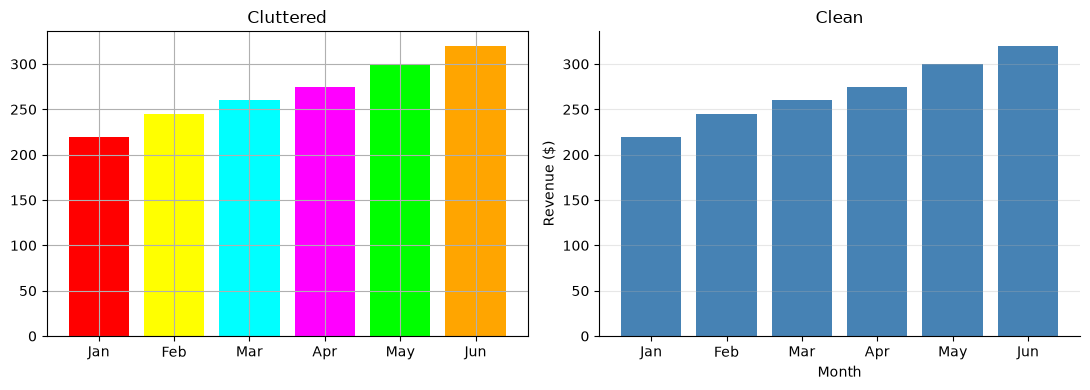

In [2]:
# Solution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

north = sales[sales["region"] == "North"]

# Cluttered: 3D-ish style bar with no labels, distracting color, no axis text
axes[0].bar(north["month"], north["revenue"], color=["red", "yellow", "cyan", "magenta", "lime", "orange"])
axes[0].set_title("Cluttered")
axes[0].grid(True, which="both", axis="both")

# Clean: single consistent color, clear labels, minimal gridlines
axes[1].bar(north["month"], north["revenue"], color="steelblue")
axes[1].set_title("Clean")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue ($)")
axes[1].grid(axis="y", alpha=0.3)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Matplotlib Line Plots

`plt.plot(x, y)` draws a line plot. Line style (`linestyle`), color (`color`), width
(`linewidth`), and marker (`marker`) control its appearance.

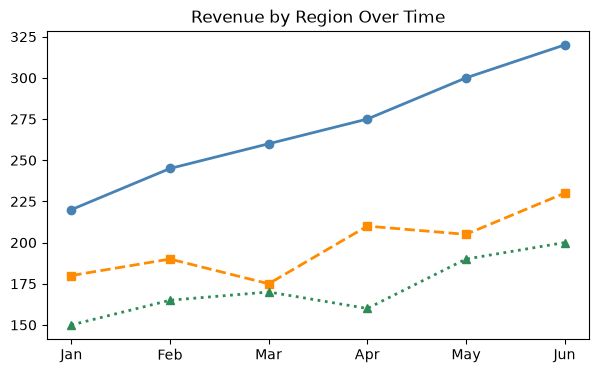

In [3]:
# Solution
regions_pivot = sales.pivot(index="month", columns="region", values="revenue").loc[months]

plt.figure(figsize=(7, 4))
plt.plot(regions_pivot.index, regions_pivot["North"], color="steelblue", linestyle="-", linewidth=2, marker="o")
plt.plot(regions_pivot.index, regions_pivot["South"], color="darkorange", linestyle="--", linewidth=2, marker="s")
plt.plot(regions_pivot.index, regions_pivot["East"], color="seagreen", linestyle=":", linewidth=2, marker="^")
plt.title("Revenue by Region Over Time")
plt.show()

## 4. Axis, Labels, Legend, Alpha & Annotation

`xlabel`/`ylabel`/`title` label the chart, `legend()` identifies each series, `alpha` controls
transparency (useful when series overlap), and `annotate()` calls out a specific point.

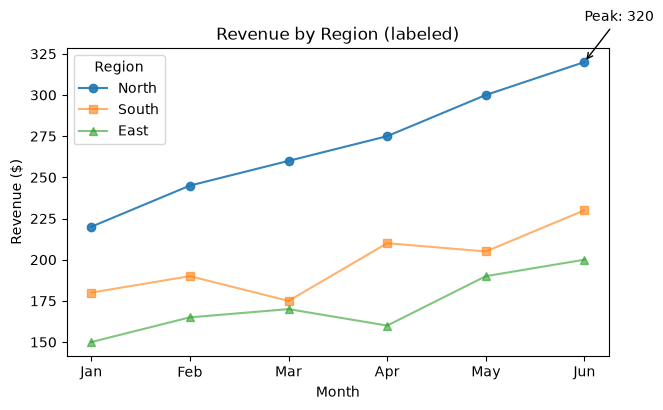

In [4]:
# Solution
plt.figure(figsize=(7, 4))
plt.plot(regions_pivot.index, regions_pivot["North"], label="North", marker="o", alpha=0.9)
plt.plot(regions_pivot.index, regions_pivot["South"], label="South", marker="s", alpha=0.6)
plt.plot(regions_pivot.index, regions_pivot["East"], label="East", marker="^", alpha=0.6)

plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.title("Revenue by Region (labeled)")
plt.legend(title="Region", loc="upper left")

peak_month = regions_pivot["North"].idxmax()
peak_value = regions_pivot["North"].max()
plt.annotate(
    f"Peak: {peak_value}",
    xy=(peak_month, peak_value),
    xytext=(peak_month, peak_value + 25),
    arrowprops=dict(arrowstyle="->", color="black"),
)
plt.show()

## 5. Multiple Plots & Subplots

`plt.subplots(rows, cols)` creates a grid of independent axes in one figure — useful for comparing
several charts side by side instead of one at a time.

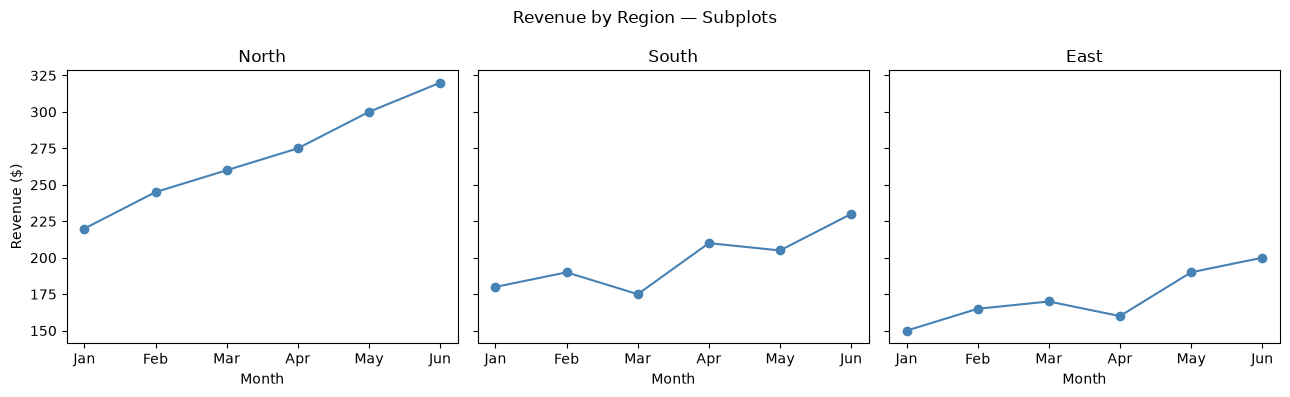

In [5]:
# Solution
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, region in zip(axes, ["North", "South", "East"]):
    subset = sales[sales["region"] == region]
    ax.plot(subset["month"], subset["revenue"], marker="o", color="steelblue")
    ax.set_title(region)
    ax.set_xlabel("Month")

axes[0].set_ylabel("Revenue ($)")
fig.suptitle("Revenue by Region — Subplots")
plt.tight_layout()
plt.show()

## 6. Scatterplots

`plt.scatter(x, y)` plots individual points — good for showing the relationship between two
numeric variables, with `s` for point size and `c` for color-by-value.

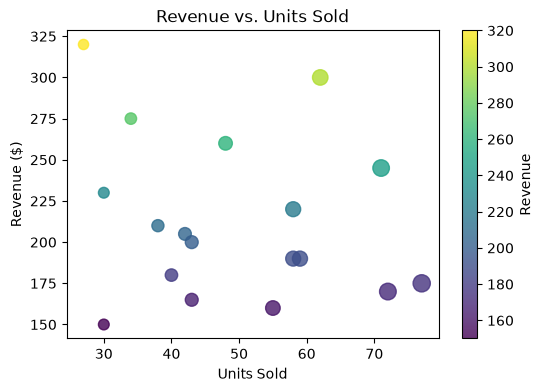

In [6]:
# Solution
plt.figure(figsize=(6, 4))
scatter = plt.scatter(sales["units"], sales["revenue"], c=sales["revenue"], s=sales["units"] * 2, cmap="viridis", alpha=0.8)
plt.xlabel("Units Sold")
plt.ylabel("Revenue ($)")
plt.title("Revenue vs. Units Sold")
plt.colorbar(scatter, label="Revenue")
plt.show()

## 7. Pie Charts

`plt.pie(values, labels=...)` shows each category's share of a whole — best used with a small
number of categories.

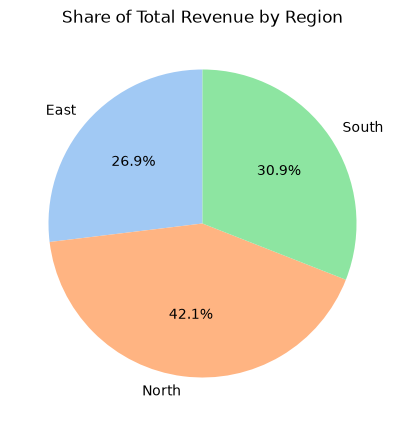

In [7]:
# Solution
totals_by_region = sales.groupby("region")["revenue"].sum()

plt.figure(figsize=(5, 5))
plt.pie(
    totals_by_region,
    labels=totals_by_region.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel"),
)
plt.title("Share of Total Revenue by Region")
plt.show()

## 8. Barplots

`plt.bar(x, height)` compares values across categories. Grouped bars (offsetting x positions)
compare sub-categories side by side.

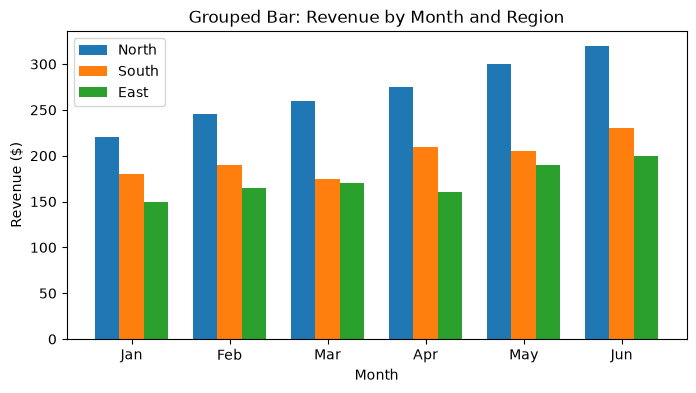

In [8]:
# Solution
width = 0.25
x = np.arange(len(months))

plt.figure(figsize=(8, 4))
plt.bar(x - width, regions_pivot["North"], width=width, label="North")
plt.bar(x, regions_pivot["South"], width=width, label="South")
plt.bar(x + width, regions_pivot["East"], width=width, label="East")

plt.xticks(x, months)
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.title("Grouped Bar: Revenue by Month and Region")
plt.legend()
plt.show()

## 9. Seaborn Overview, Boxplots & Distribution Plots

Seaborn functions take a `data=` DataFrame plus column names, and compute statistical summaries
automatically. A **boxplot** shows the median, quartiles, and outliers per category; a
**distribution plot** (`histplot`/`kdeplot`) shows the shape of a numeric variable.

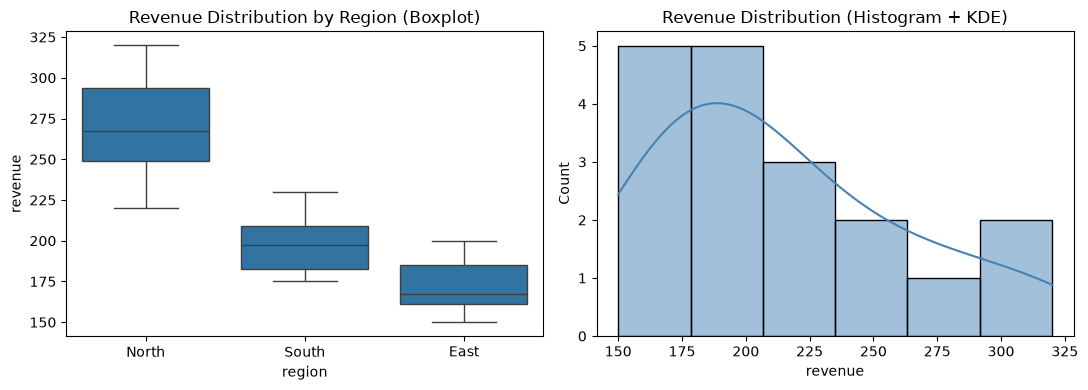

In [9]:
# Solution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=sales, x="region", y="revenue", ax=axes[0])
axes[0].set_title("Revenue Distribution by Region (Boxplot)")

sns.histplot(sales["revenue"], kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Revenue Distribution (Histogram + KDE)")

plt.tight_layout()
plt.show()

## 10. Heatmaps

`sns.heatmap()` renders a matrix of values as color, with optional numeric annotations — a
common way to show a correlation matrix or a pivoted table at a glance.

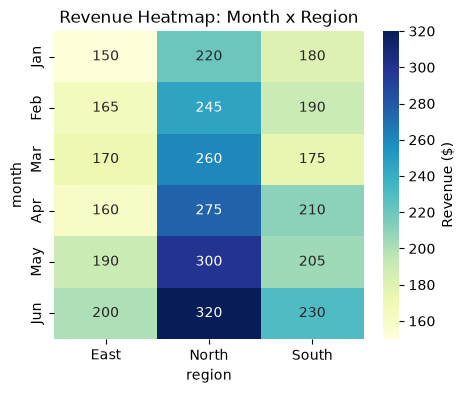

In [10]:
# Solution
plt.figure(figsize=(5, 4))
sns.heatmap(regions_pivot, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Revenue ($)"})
plt.title("Revenue Heatmap: Month x Region")
plt.show()

## 11. Swarmplots & Countplots

A **swarmplot** plots every individual data point, offset so they don't overlap — showing the
raw distribution per category instead of just a summary. A **countplot** counts how many rows
fall into each category.

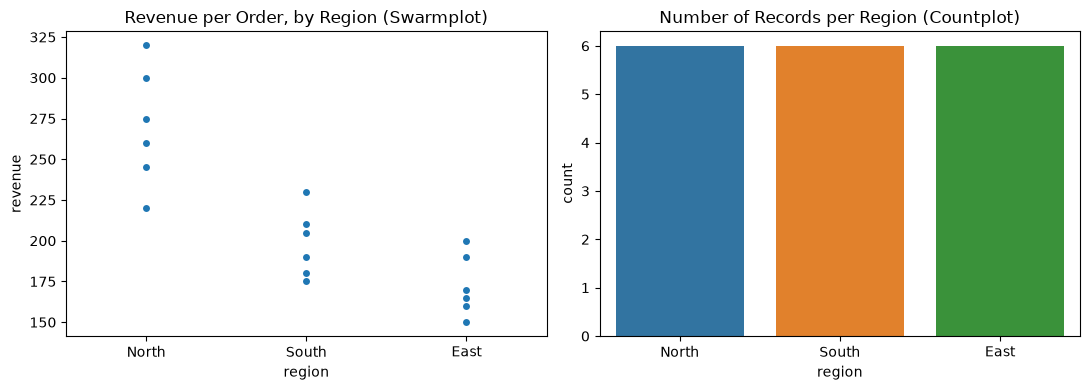

In [11]:
# Solution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.swarmplot(data=sales, x="region", y="revenue", ax=axes[0])
axes[0].set_title("Revenue per Order, by Region (Swarmplot)")

sns.countplot(data=sales, x="region", ax=axes[1], hue="region", legend=False)
axes[1].set_title("Number of Records per Region (Countplot)")

plt.tight_layout()
plt.show()

## 12. Pointplots

`sns.pointplot()` plots a summary statistic (the mean, by default) per category as a point with
a confidence interval, connected by a line — useful for comparing trends across groups.

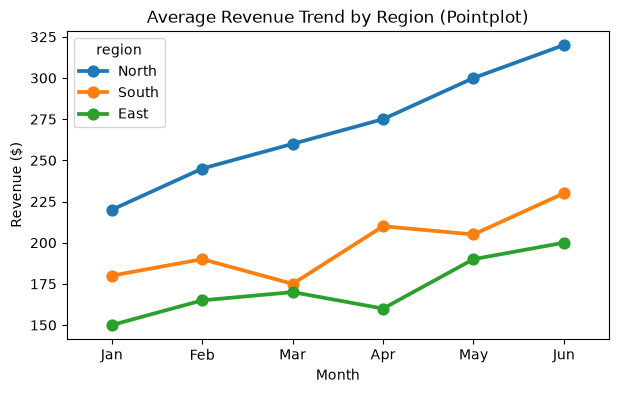

In [12]:
# Solution
plt.figure(figsize=(7, 4))
sns.pointplot(data=sales, x="month", y="revenue", hue="region", order=months, errorbar=None)
plt.title("Average Revenue Trend by Region (Pointplot)")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.show()